# 🛒 Online Retail II — Data Cleaning, Transformation & Visualization

**Dataset:** Online Retail II UCI (Kaggle)

**What we will do:**

| Step | Task |
|------|------|
| 0 | First Look at the Data |
| 1 | Remove Duplicates |
| 2 | Column: Invoice (cancelled orders) |
| 3 | Column: Description (messy text) |
| 4 | Column: Quantity (negatives) |
| 5 | Column: Price (zeros & negatives) |
| 6 | Column: Customer ID (missing values) |
| 7 | Column: InvoiceDate (date parsing) |
| 8 | Column: Country (standardize) |
| 9 | Transformation (new features) |
| 10 | Visualization (charts & insights) |
| 11 | Final Summary |


---
## Setup — Import Libraries & Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style for all plots
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print('Libraries loaded!')

Libraries loaded!


In [10]:
# Load the dataset
# encoding='latin-1' is needed because file has special characters like £
df = pd.read_csv('online_retail_II.csv.zip', encoding='latin-1')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded successfully!
Shape: 1,067,371 rows × 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


---
## Step 0 — First Look at the Data
Before fixing anything, we look at everything first.

Goal: understand what columns exist, their types, and spot obvious problems.

In [ ]:
# What columns do we have and what are their data types?
df.dtypes
# 'object' means text/string
# InvoiceDate is object but should be datetime
# Customer ID is float but should be integer (IDs don't have decimals)

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [ ]:
print('Rows:   ', df.shape[0])
print('Columns:', df.shape[1])

Rows:    1067371
Columns: 8


In [ ]:
# Check missing values
missing = pd.DataFrame({
    'Missing Count':   df.isnull().sum(),
    'Missing Percent': (df.isnull().sum() / len(df) * 100).round(2)
})
print('Missing values per column:')
print(missing[missing['Missing Count'] > 0])

Missing values per column:
             Missing Count  Missing Percent
Description           4382             0.41
Customer ID         243007            22.77


In [ ]:
# Statistical summary
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


---
## Step 1 — Duplicates
We check for duplicate rows FIRST before cleaning anything.

Why first? Because if we clean first and THEN remove duplicates,
we waste time cleaning rows that will be deleted anyway.

### Identifying duplicate rows

In [ ]:
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 34335


In [ ]:
# Show the actual duplicate rows
df[df.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


### Solving — remove duplicate rows

In [ ]:
# keep='first' means: keep the first time a row appears, delete the rest
df = df.drop_duplicates(keep='first')

# reset_index fixes the row numbers after deleting rows
# drop=True means: don't save the old numbers as a new column
df = df.reset_index(drop=True)

print('Rows after removing duplicates:', f'{df.shape[0]:,}')

Rows after removing duplicates: 1,033,036


---
## Step 2 — Column: Invoice (Cancelled Orders)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'Invoice' column

In [ ]:
# Look at sample values
print('Sample Invoice values:')
print(df['Invoice'].unique()[:20])
print()

# Invoices starting with 'C' are CANCELLED orders
# These are RETURNS — not real sales, so they have negative quantities
cancelled_mask = df['Invoice'].astype(str).str.startswith('C')
print(f'Cancelled orders (Invoice starts with C): {cancelled_mask.sum():,}')
print()
print('Sample cancelled order:')
df[cancelled_mask].head(3)

Sample Invoice values:
['489434' '489435' '489436' '489437' '489438' '489439' '489440' '489441'
 '489442' '489443' '489444' '489445' '489446' '489447' '489448' 'C489449'
 '489450' 'C489459' '489460' '489461']

Cancelled orders (Invoice starts with C): 19,104

Sample cancelled order:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia


### Solving — add a flag, then remove cancelled orders

In [ ]:
# First: add a flag column so we know which ones were cancelled
# True = cancelled, False = normal order
df['is_cancelled'] = df['Invoice'].astype(str).str.startswith('C')

print('is_cancelled value counts:')
print(df['is_cancelled'].value_counts())
print()

# Now: remove cancelled orders — we only want actual sales
df = df[df['is_cancelled'] == False].copy()
df = df.drop(columns=['is_cancelled'])
df = df.reset_index(drop=True)

print(f'Rows after removing cancelled orders: {df.shape[0]:,}')

is_cancelled value counts:
is_cancelled
False    1013932
True       19104
Name: count, dtype: int64

Rows after removing cancelled orders: 1,013,932


---
## Step 3 — Column: Description (Messy Text)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'Description' column

In [ ]:
# Issues we can see:
# 1. Extra spaces: ' WHITE CHERRY LIGHTS' has leading space
# 2. ALL CAPS — inconsistent, should be Title Case
# 3. Missing values (NaN)

print('Missing descriptions:', df['Description'].isnull().sum())
print()
print('Sample values (notice extra spaces and all caps):')
print(df['Description'].unique()[:15])

Missing descriptions: 4275

Sample values (notice extra spaces and all caps):
['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' 'RECORD FRAME 7" SINGLE SIZE '
 'STRAWBERRY CERAMIC TRINKET BOX' 'PINK DOUGHNUT TRINKET POT '
 'SAVE THE PLANET MUG' 'FANCY FONT HOME SWEET HOME DOORMAT' 'CAT BOWL '
 'DOG BOWL , CHASING BALL DESIGN' 'HEART MEASURING SPOONS LARGE'
 'LUNCHBOX WITH CUTLERY FAIRY CAKES ' 'DOOR MAT BLACK FLOCK '
 'LOVE BUILDING BLOCK WORD' 'HOME BUILDING BLOCK WORD']


### Solving issues in 'Description' column

In [ ]:
# ISSUE 1 FIX: remove extra spaces from start and end
# ISSUE 2 FIX: convert to Title Case
print('Before cleaning:')
print(df['Description'].unique()[:8])

df['Description'] = df['Description'].str.strip()
df['Description'] = df['Description'].str.title()

print()
print('After cleaning:')
print(df['Description'].unique()[:8])

Before cleaning:
['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' 'RECORD FRAME 7" SINGLE SIZE '
 'STRAWBERRY CERAMIC TRINKET BOX' 'PINK DOUGHNUT TRINKET POT '
 'SAVE THE PLANET MUG' 'FANCY FONT HOME SWEET HOME DOORMAT']

After cleaning:
['15Cm Christmas Glass Ball 20 Lights' 'Pink Cherry Lights'
 'White Cherry Lights' 'Record Frame 7" Single Size'
 'Strawberry Ceramic Trinket Box' 'Pink Doughnut Trinket Pot'
 'Save The Planet Mug' 'Fancy Font Home Sweet Home Doormat']


In [ ]:
# ISSUE 3 FIX: fill missing descriptions with 'Unknown Product'
df['Description'] = df['Description'].fillna('Unknown Product')

print('Missing descriptions after fix:', df['Description'].isnull().sum())

Missing descriptions after fix: 0


---
## Step 4 — Column: Quantity (Negative Values)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'Quantity' column

In [ ]:
print('Quantity statistics:')
print(df['Quantity'].describe())
print()
print('Negative quantities:', (df['Quantity'] < 0).sum())
print('Zero quantities:    ', (df['Quantity'] == 0).sum())
print()
# Issues:
# 1. Negative quantities — these are returns (we already removed C invoices
#    but some negative quantities still remain)
# 2. Zero quantities — no items ordered = invalid row

Quantity statistics:
count    1.013932e+06
mean     1.073701e+01
std      1.373870e+02
min     -9.600000e+03
25%      1.000000e+00
50%      3.000000e+00
75%      1.200000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

Negative quantities: 3393
Zero quantities:     0



### Solving issues in 'Quantity' column

In [ ]:
# Remove rows where quantity is zero or negative
# A valid sale must have at least 1 item
print('Rows before:', f'{len(df):,}')

df = df[df['Quantity'] > 0].copy()
df = df.reset_index(drop=True)

print('Rows after removing invalid quantities:', f'{len(df):,}')
print()
print('Quantity range now:')
print('  Min:', df['Quantity'].min())
print('  Max:', df['Quantity'].max())

Rows before: 1,013,932
Rows after removing invalid quantities: 1,010,539

Quantity range now:
  Min: 1
  Max: 80995


---
## Step 5 — Column: Price (Zeros & Negatives)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'Price' column

In [ ]:
print('Price statistics:')
print(df['Price'].describe())
print()
print('Zero prices:    ', (df['Price'] == 0).sum())
print('Negative prices:', (df['Price'] < 0).sum())
print()
# Issues:
# 1. Zero prices — free items or data entry error
# 2. Negative prices — impossible, price cannot be negative

Price statistics:
count    1.010539e+06
mean     3.906643e+00
std      9.508158e+01
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.130000e+00
max      2.511109e+04
Name: Price, dtype: float64

Zero prices:     2621
Negative prices: 5



### Solving issues in 'Price' column

In [ ]:
# Remove rows with zero or negative price
# A valid product must have a price greater than 0
print('Rows before:', f'{len(df):,}')

df = df[df['Price'] > 0].copy()
df = df.reset_index(drop=True)

print('Rows after removing invalid prices:', f'{len(df):,}')
print()
print('Price range now:')
print('  Min: £', df['Price'].min())
print('  Max: £', df['Price'].max())

Rows before: 1,010,539
Rows after removing invalid prices: 1,007,913

Price range now:
  Min: £ 0.001
  Max: £ 25111.09


---
## Step 6 — Column: Customer ID (Missing Values)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'Customer ID' column

In [ ]:
print('Data type:', df['Customer ID'].dtype)
print()
print('Missing Customer IDs:', df['Customer ID'].isnull().sum())
print('Missing percent:     ', round(df['Customer ID'].isnull().sum() / len(df) * 100, 1), '%')
print()
print('Sample values:', df['Customer ID'].dropna().unique()[:10])
print()
# Issues:
# 1. Customer ID is float (12345.0) — should be integer (12345)
# 2. 22% rows have no Customer ID — these are guest/anonymous purchases
#    We cannot know WHO bought, so we label them 'Guest'

Data type: float64

Missing Customer IDs: 228488
Missing percent:      22.7 %

Sample values: [13085. 13078. 15362. 18102. 12682. 18087. 13635. 14110. 12636. 17519.]



### Solving issues in 'Customer ID' column

In [ ]:
# ISSUE 2 FIX: fill missing IDs with 0 (represents Guest/Anonymous)
df['Customer ID'] = df['Customer ID'].fillna(0)

# ISSUE 1 FIX: convert float to integer
# 12345.0 -> 12345 (IDs should not have decimals)
df['Customer ID'] = df['Customer ID'].astype(int)

# Rename for cleaner column name
df = df.rename(columns={'Customer ID': 'CustomerID'})

print('Data type after fix:', df['CustomerID'].dtype)
print('Missing values:', df['CustomerID'].isnull().sum())
print()
print('Sample values:', df['CustomerID'].unique()[:10])

Data type after fix: int64
Missing values: 0

Sample values: [13085 13078 15362 18102 12682 18087 13635 14110 12636 17519]


---
## Step 7 — Column: InvoiceDate (Date Parsing)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'InvoiceDate' column

In [ ]:
print('Data type:', df['InvoiceDate'].dtype)
print()
print('Sample values:')
print(df['InvoiceDate'].unique()[:10])
print()
# Issues:
# 1. InvoiceDate is 'object' (text) — needs to be datetime type
# 2. Without datetime type, we CANNOT do time-based analysis
#    (monthly sales, trends, etc.)

Data type: object

Sample values:
['2009-12-01 07:45:00' '2009-12-01 07:46:00' '2009-12-01 09:06:00'
 '2009-12-01 09:08:00' '2009-12-01 09:24:00' '2009-12-01 09:28:00'
 '2009-12-01 09:43:00' '2009-12-01 09:44:00' '2009-12-01 09:46:00'
 '2009-12-01 09:50:00']



### Solving issues in 'InvoiceDate' column

In [ ]:
# Convert text to proper datetime format
# errors='coerce' — if any date can't be parsed, make it NaN instead of crashing
print('Before:', df['InvoiceDate'].dtype)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print('After: ', df['InvoiceDate'].dtype)
print()
print('Date range in dataset:')
print('  Earliest:', df['InvoiceDate'].min())
print('  Latest:  ', df['InvoiceDate'].max())
print()
print('Any failed conversions (NaT):', df['InvoiceDate'].isnull().sum())

Before: object
After:  datetime64[ns]

Date range in dataset:
  Earliest: 2009-12-01 07:45:00
  Latest:   2011-12-09 12:50:00

Any failed conversions (NaT): 0


---
## Step 8 — Column: Country (Standardize)
Let's look at it, find all problems, then fix them one by one.

### Identifying issues in 'Country' column

In [ ]:
print('All unique country values:')
print(df['Country'].unique())
print()
print('Value counts:')
print(df['Country'].value_counts())
print()
# Issues:
# 1. 'EIRE' is old name for Ireland — should be 'Ireland' for consistency
# 2. 'RSA' should be 'South Africa'
# 3. 'Unspecified' — unknown country

All unique country values:
['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Denmark' 'Netherlands' 'Poland' 'Channel Islands' 'Spain'
 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden' 'United Arab Emirates'
 'Finland' 'Italy' 'Switzerland' 'Japan' 'Unspecified' 'Nigeria' 'Malta'
 'Bahrain' 'RSA' 'Bermuda' 'Hong Kong' 'Singapore' 'Thailand' 'Israel'
 'Lithuania' 'West Indies' 'Lebanon' 'Korea' 'Brazil' 'Canada' 'Iceland'
 'Saudi Arabia' 'Czech Republic' 'European Community']

Value counts:
Country
United Kingdom          926038
EIRE                     17154
Germany                  16432
France                   13639
Netherlands               5085
Spain                     3662
Switzerland               3122
Belgium                   3055
Portugal                  2470
Australia                 1789
Channel Islands           1551
Italy                     1442
Sweden                    1336
Norway                    1289
Cyprus                    1136


### Solving issues in 'Country' column

In [ ]:
# ISSUE 1 & 2 FIX: replace old/abbreviation names with proper names
print('Before replace:')
print(df['Country'].value_counts().tail(10))

df['Country'] = df['Country'].replace({
    'EIRE':        'Ireland',
    'RSA':         'South Africa',
    'Unspecified': 'Unknown'
})

print()
print('After replace — unique values:')
print(sorted(df['Country'].unique()))

Before replace:
Country
Brazil                94
Thailand              76
European Community    60
Lebanon               57
West Indies           54
Korea                 53
Bermuda               34
Nigeria               30
Czech Republic        25
Saudi Arabia           9
Name: count, dtype: int64

After replace — unique values:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Bermuda', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unknown', 'West Indies']


### Final Check — All Columns After Cleaning

In [ ]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== SHAPE ===')
print(f'{df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head()

=== DATA TYPES ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID              int64
Country                object
dtype: object

=== MISSING VALUES ===
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

=== SHAPE ===
1,007,913 rows × 8 columns



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15Cm Christmas Glass Ball 20 Lights,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,Pink Cherry Lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,White Cherry Lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"Record Frame 7"" Single Size",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,Strawberry Ceramic Trinket Box,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


---
## Step 9 — Transformation (Adding New Features)

Now we create new columns from existing data.
This is called **Feature Engineering** — turning raw data into useful information.

| New Column | How | Why |
|------------|-----|-----|
| `Revenue` | Price × Quantity | Total money earned per row |
| `Year` | from InvoiceDate | For yearly comparison |
| `Month` | from InvoiceDate | For monthly trends |
| `Month_Name` | from InvoiceDate | Human readable month |
| `Day_of_Week` | from InvoiceDate | Which day sells most |
| `Hour` | from InvoiceDate | Which hour is busiest |
| `Is_Weekend` | from InvoiceDate | Weekend vs weekday sales |
| `Price_Tier` | pd.cut on Price | Budget / Mid / Premium |
| `Is_Guest` | CustomerID == 0 | Guest vs registered customer |

In [ ]:
# TRANSFORMATION 1: Revenue = Price × Quantity
# This is the most important feature — how much money each row made
df['Revenue'] = (df['Price'] * df['Quantity']).round(2)

print('Revenue column added!')
print('Sample:')
print(df[['Description', 'Price', 'Quantity', 'Revenue']].head(5))

Revenue column added!
Sample:
                           Description  Price  Quantity  Revenue
0  15Cm Christmas Glass Ball 20 Lights   6.95        12     83.4
1                   Pink Cherry Lights   6.75        12     81.0
2                  White Cherry Lights   6.75        12     81.0
3          Record Frame 7" Single Size   2.10        48    100.8
4       Strawberry Ceramic Trinket Box   1.25        24     30.0


In [ ]:
# TRANSFORMATION 2: Extract date parts from InvoiceDate
# .dt accessor unlocks all datetime features

df['Year']         = df['InvoiceDate'].dt.year
df['Month']        = df['InvoiceDate'].dt.month
df['Month_Name']   = df['InvoiceDate'].dt.strftime('%B')   # 'January', 'February'...
df['Day_of_Week']  = df['InvoiceDate'].dt.day_name()       # 'Monday', 'Tuesday'...
df['Hour']         = df['InvoiceDate'].dt.hour
df['Is_Weekend']   = df['InvoiceDate'].dt.dayofweek >= 5   # Mon=0 Sun=6, so >=5 is weekend

print('Date features added!')
print(df[['InvoiceDate', 'Year', 'Month', 'Month_Name', 'Day_of_Week', 'Hour', 'Is_Weekend']].head(5))

Date features added!
          InvoiceDate  Year  Month Month_Name Day_of_Week  Hour  Is_Weekend
0 2009-12-01 07:45:00  2009     12   December     Tuesday     7       False
1 2009-12-01 07:45:00  2009     12   December     Tuesday     7       False
2 2009-12-01 07:45:00  2009     12   December     Tuesday     7       False
3 2009-12-01 07:45:00  2009     12   December     Tuesday     7       False
4 2009-12-01 07:45:00  2009     12   December     Tuesday     7       False


In [ ]:
# TRANSFORMATION 3: Price Tier — categorize products by price
# pd.cut() divides a number column into named buckets
# bins = the price boundaries
# labels = names for each bucket

df['Price_Tier'] = pd.cut(
    df['Price'],
    bins   = [0, 2, 5, 15, float('inf')],
    labels = ['Budget (£0-2)', 'Low (£2-5)', 'Mid (£5-15)', 'Premium (£15+)']
)

print('Price Tier distribution:')
print(df['Price_Tier'].value_counts())

Price Tier distribution:
Price_Tier
Budget (£0-2)     474113
Low (£2-5)        358445
Mid (£5-15)       157464
Premium (£15+)     17891
Name: count, dtype: int64


In [ ]:
# TRANSFORMATION 4: Is_Guest — was this a guest (no account) purchase?
# CustomerID == 0 means we filled it with 0 earlier (was missing = guest)

df['Is_Guest'] = df['CustomerID'] == 0

print('Guest vs Registered customers:')
print(df['Is_Guest'].value_counts())
print()
guest_pct = df['Is_Guest'].mean() * 100
print(f'Guest purchases: {guest_pct:.1f}%')

Guest vs Registered customers:
Is_Guest
False    779425
True     228488
Name: count, dtype: int64

Guest purchases: 22.7%


In [ ]:
# Final look at our transformed dataset
print('Final dataset shape:', df.shape)
print()
print('All columns now:')
print(df.columns.tolist())
print()
df.head()

Final dataset shape: (1007913, 17)

All columns now:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day_of_Week', 'Hour', 'Is_Weekend', 'Price_Tier', 'Is_Guest']



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,Year,Month,Month_Name,Day_of_Week,Hour,Is_Weekend,Price_Tier,Is_Guest
0,489434,85048,15Cm Christmas Glass Ball 20 Lights,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,December,Tuesday,7,False,Mid (£5-15),False
1,489434,79323P,Pink Cherry Lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,Tuesday,7,False,Mid (£5-15),False
2,489434,79323W,White Cherry Lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,Tuesday,7,False,Mid (£5-15),False
3,489434,22041,"Record Frame 7"" Single Size",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,December,Tuesday,7,False,Low (£2-5),False
4,489434,21232,Strawberry Ceramic Trinket Box,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,December,Tuesday,7,False,Budget (£0-2),False


---
## Step 10 — Visualization

Now we turn our clean data into visual insights.

Charts we will make:
1. Monthly Revenue Trend
2. Top 10 Products by Revenue
3. Sales by Day of Week
4. Sales by Hour of Day
5. Top 10 Countries by Revenue
6. Price Tier Distribution
7. Guest vs Registered Customer Revenue
8. Yearly Revenue Comparison

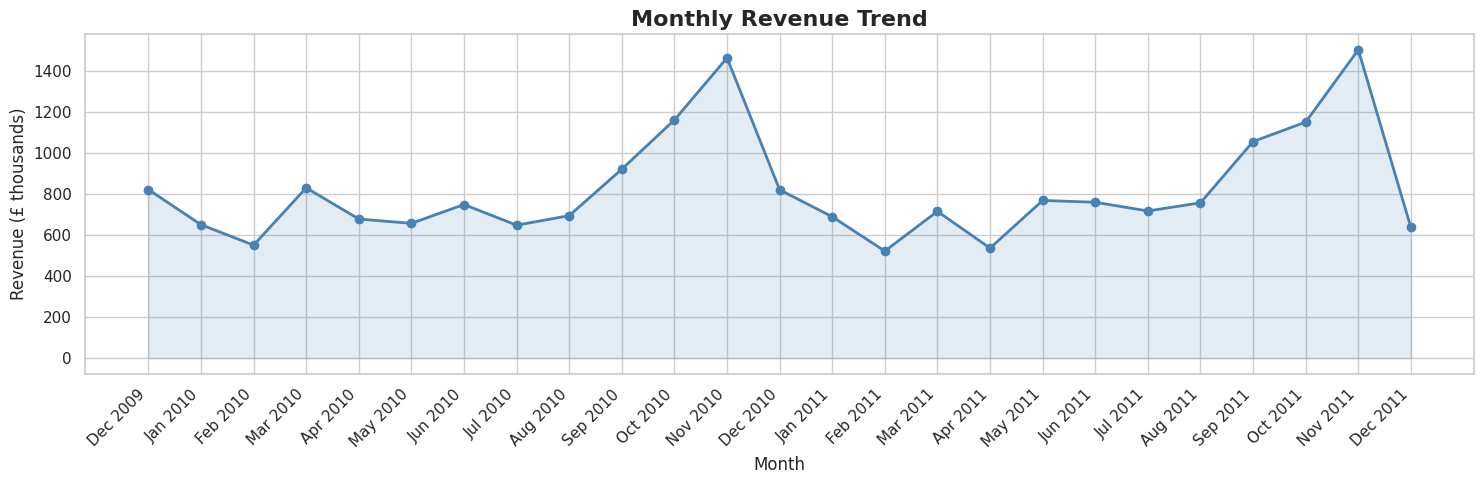

In [ ]:
# ── CHART 1: Monthly Revenue Trend ──────────────────────────────────────

# Group by Year + Month to get monthly totals
monthly = (
    df.groupby(['Year', 'Month', 'Month_Name'])['Revenue']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)
# Create a label like 'Jan 2010'
monthly['Label'] = monthly['Month_Name'].str[:3] + ' ' + monthly['Year'].astype(str)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly['Label'], monthly['Revenue'] / 1000, marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly['Label'], monthly['Revenue'] / 1000, alpha=0.15, color='steelblue')
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£ thousands)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

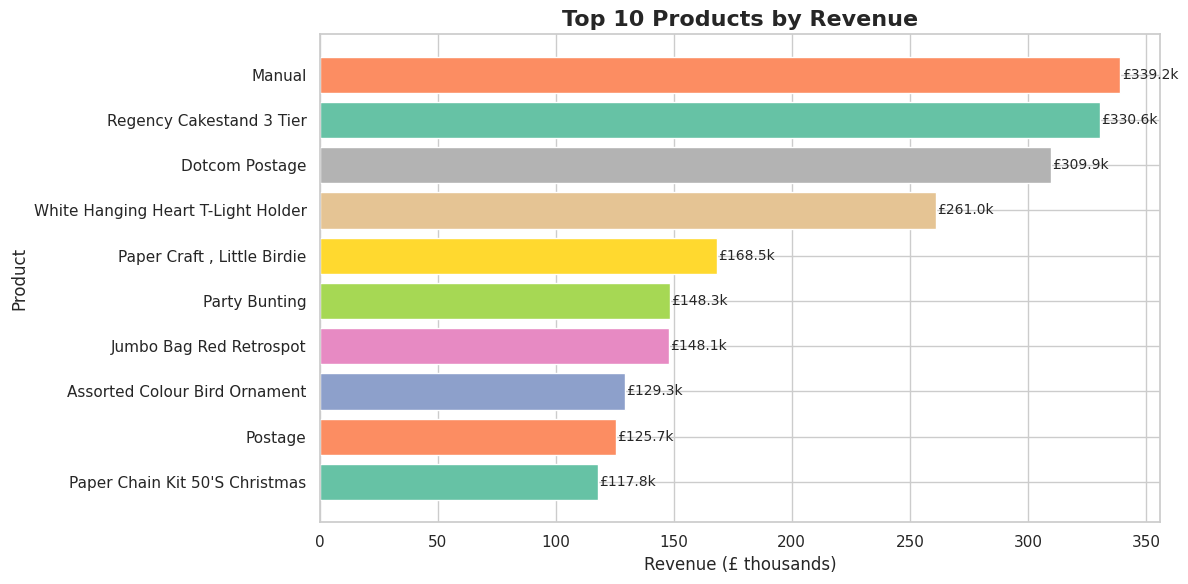

In [ ]:
# ── CHART 2: Top 10 Products by Revenue ─────────────────────────────────

top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_products['Description'][::-1],
               top_products['Revenue'][::-1] / 1000,
               color=sns.color_palette('Set2', 10))
ax.set_title('Top 10 Products by Revenue', fontsize=16, fontweight='bold')
ax.set_xlabel('Revenue (£ thousands)')
ax.set_ylabel('Product')

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'£{width:.1f}k', va='center', fontsize=10)

plt.tight_layout()
plt.show()

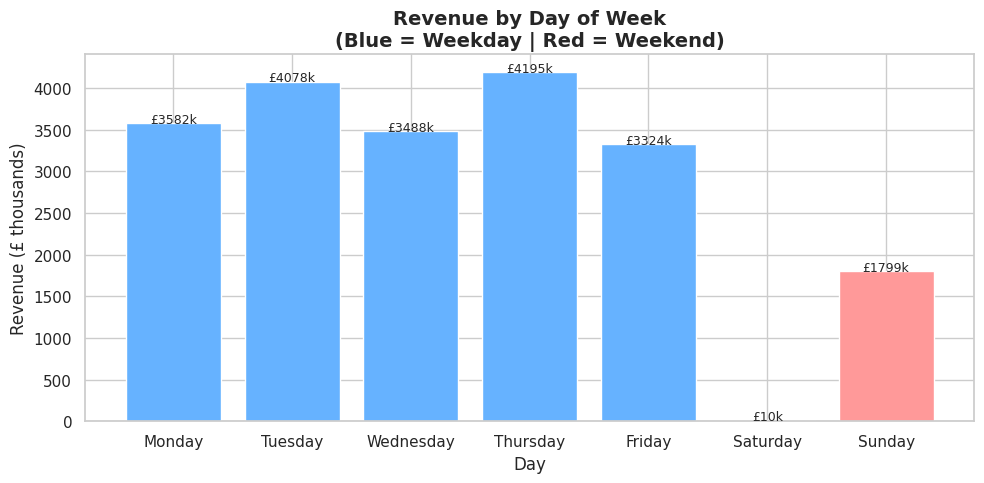

In [ ]:
# ── CHART 3: Sales by Day of Week ───────────────────────────────────────

# Order days properly (Mon to Sun)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = (
    df.groupby('Day_of_Week')['Revenue']
    .sum()
    .reindex(day_order)
    .reset_index()
)

colors = ['#FF9999' if d in ['Saturday', 'Sunday'] else '#66B2FF' for d in day_order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_sales['Day_of_Week'], day_sales['Revenue'] / 1000, color=colors)
ax.set_title('Revenue by Day of Week\n(Blue = Weekday | Red = Weekend)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Revenue (£ thousands)')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'£{height:.0f}k', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

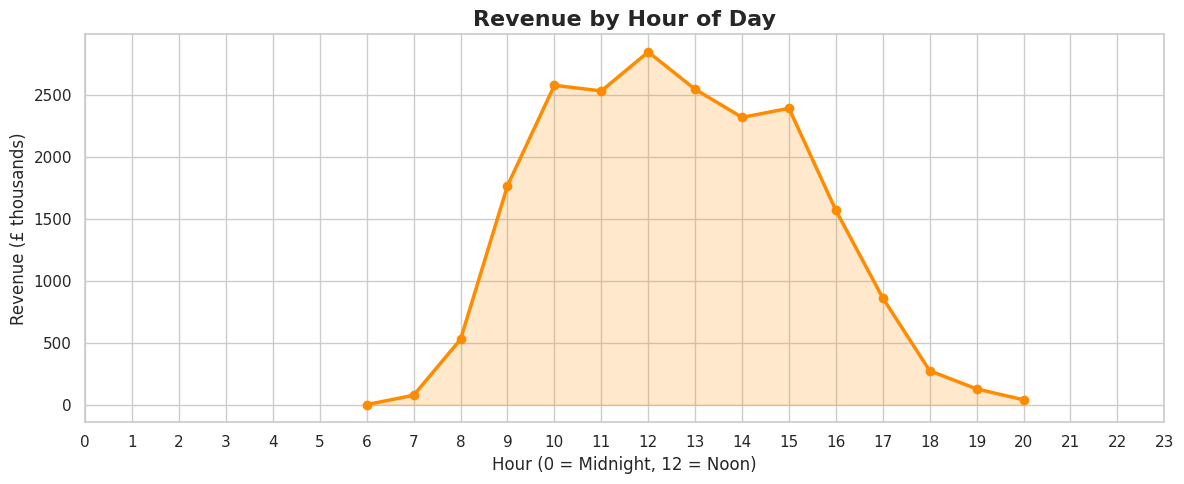

In [ ]:
# ── CHART 4: Sales by Hour of Day ───────────────────────────────────────

hourly = df.groupby('Hour')['Revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly['Hour'], hourly['Revenue'] / 1000,
        marker='o', color='darkorange', linewidth=2.5)
ax.fill_between(hourly['Hour'], hourly['Revenue'] / 1000, alpha=0.2, color='darkorange')
ax.set_title('Revenue by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Revenue (£ thousands)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

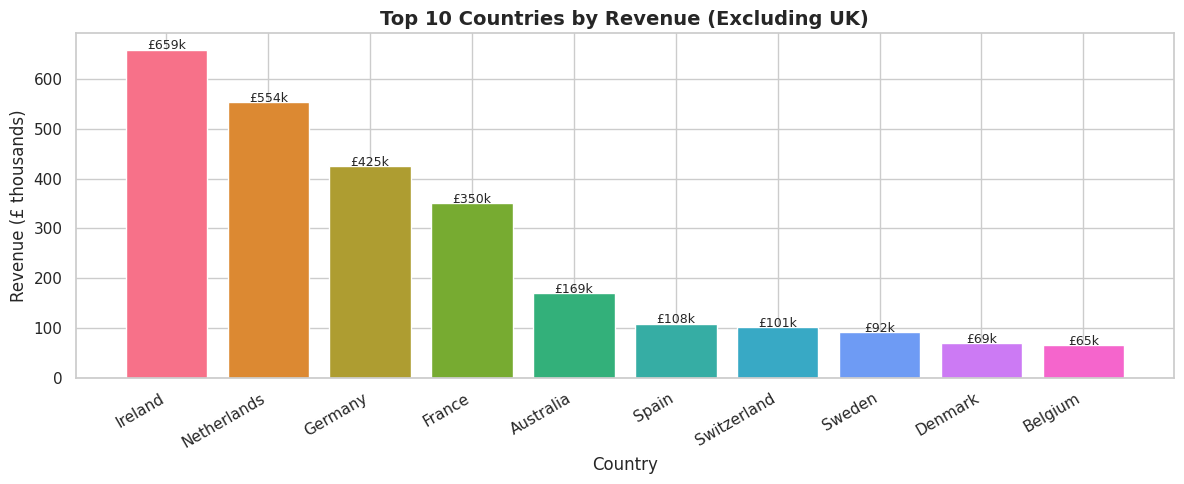

In [ ]:
# ── CHART 5: Top 10 Countries by Revenue ────────────────────────────────

# Exclude UK since it dominates and makes others invisible
top_countries = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_countries['Country'], top_countries['Revenue'] / 1000,
              color=sns.color_palette('husl', 10))
ax.set_title('Top 10 Countries by Revenue (Excluding UK)', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue (£ thousands)')
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'£{height:.0f}k', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

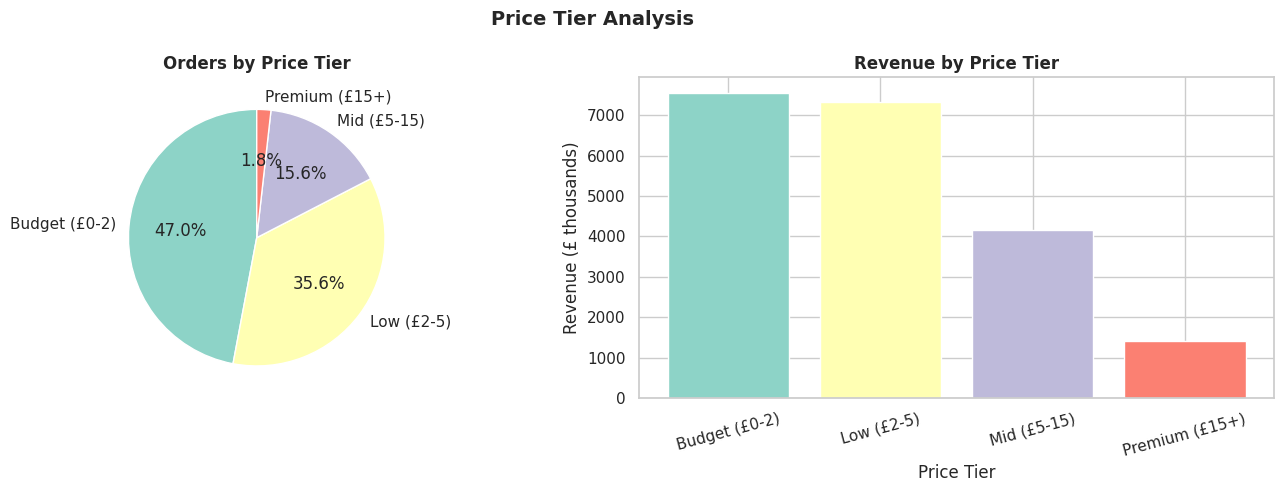

In [ ]:
# ── CHART 6: Price Tier Distribution ────────────────────────────────────

tier_data = df['Price_Tier'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — count of orders
ax1.pie(tier_data.values, labels=tier_data.index,
        autopct='%1.1f%%', colors=sns.color_palette('Set3', 4),
        startangle=90)
ax1.set_title('Orders by Price Tier', fontweight='bold')

# Bar chart — revenue per tier
tier_revenue = df.groupby('Price_Tier', observed=True)['Revenue'].sum().sort_index()
ax2.bar(tier_revenue.index, tier_revenue.values / 1000,
        color=sns.color_palette('Set3', 4))
ax2.set_title('Revenue by Price Tier', fontweight='bold')
ax2.set_xlabel('Price Tier')
ax2.set_ylabel('Revenue (£ thousands)')
plt.xticks(rotation=15)

plt.suptitle('Price Tier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Guest vs Registered Customers:
                     Total Revenue  Avg Revenue per Order  Order Count
Registered Customer    17374804.25                  22.29       779425
Guest                   3101456.18                  13.57       228488


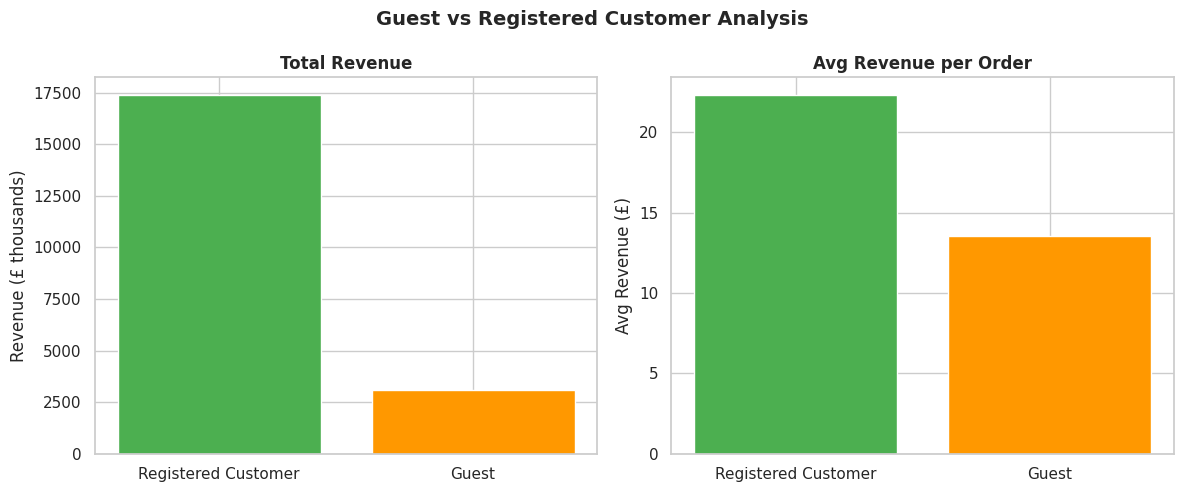

In [ ]:
# ── CHART 7: Guest vs Registered Customer Revenue ────────────────────────

customer_type = df.groupby('Is_Guest')['Revenue'].agg(['sum', 'mean', 'count'])
customer_type.index = ['Registered Customer', 'Guest']
customer_type.columns = ['Total Revenue', 'Avg Revenue per Order', 'Order Count']
customer_type = customer_type.round(2)

print('Guest vs Registered Customers:')
print(customer_type)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4CAF50', '#FF9800']

# Total Revenue
axes[0].bar(customer_type.index, customer_type['Total Revenue'] / 1000, color=colors)
axes[0].set_title('Total Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (£ thousands)')

# Avg Revenue per Order
axes[1].bar(customer_type.index, customer_type['Avg Revenue per Order'], color=colors)
axes[1].set_title('Avg Revenue per Order', fontweight='bold')
axes[1].set_ylabel('Avg Revenue (£)')

plt.suptitle('Guest vs Registered Customer Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

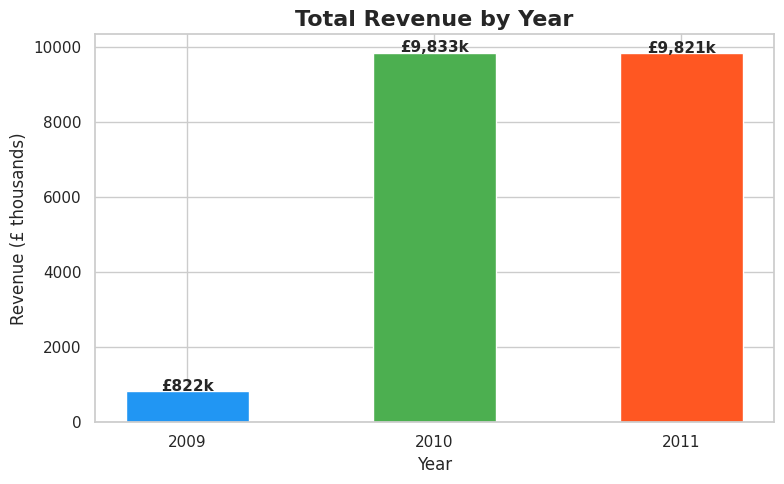

In [ ]:
# ── CHART 8: Yearly Revenue Comparison ──────────────────────────────────

yearly = df.groupby('Year')['Revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yearly['Year'].astype(str), yearly['Revenue'] / 1000,
              color=['#2196F3', '#4CAF50', '#FF5722'][:len(yearly)], width=0.5)
ax.set_title('Total Revenue by Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (£ thousands)')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10,
            f'£{height:,.0f}k', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 11 — Final Business Summary Report

In [ ]:
total_revenue    = df['Revenue'].sum()
total_orders     = df['Invoice'].nunique()
total_customers  = df[df['CustomerID'] != 0]['CustomerID'].nunique()
total_products   = df['Description'].nunique()
avg_order_value  = df.groupby('Invoice')['Revenue'].sum().mean()
top_product      = df.groupby('Description')['Revenue'].sum().idxmax()
top_country      = df.groupby('Country')['Revenue'].sum().idxmax()
best_month       = df.groupby('Month_Name')['Revenue'].sum().idxmax()
best_day         = df.groupby('Day_of_Week')['Revenue'].sum().idxmax()
best_hour        = df.groupby('Hour')['Revenue'].sum().idxmax()

print('=' * 55)
print('       ONLINE RETAIL — BUSINESS SUMMARY REPORT')
print('=' * 55)
print(f'  Total Revenue       : £{total_revenue:>14,.2f}')
print(f'  Total Orders        : {total_orders:>15,}')
print(f'  Unique Customers    : {total_customers:>15,}')
print(f'  Unique Products     : {total_products:>15,}')
print(f'  Avg Order Value     : £{avg_order_value:>14,.2f}')
print('-' * 55)
print(f'  Top Product         : {top_product}')
print(f'  Top Country         : {top_country}')
print(f'  Best Month          : {best_month}')
print(f'  Best Day of Week    : {best_day}')
print(f'  Peak Hour           : {best_hour}:00')
print('=' * 55)

       ONLINE RETAIL — BUSINESS SUMMARY REPORT
  Total Revenue       : £ 20,476,260.43
  Total Orders        :          40,077
  Unique Customers    :           5,878
  Unique Products     :           5,356
  Avg Order Value     : £        510.92
-------------------------------------------------------
  Top Product         : Manual
  Top Country         : United Kingdom
  Best Month          : November
  Best Day of Week    : Thursday
  Peak Hour           : 12:00
